Dataset Shape: (20000, 27)
             timestamp city_zone  traffic_density  avg_speed_kmph  \
0  2024-01-01 00:00:00    Zone_D               10              15   
1  2024-01-01 00:01:00    Zone_E              113              36   
2  2024-01-01 00:02:00    Zone_C               74              19   
3  2024-01-01 00:03:00    Zone_E               10              48   
4  2024-01-01 00:04:00    Zone_E              134              46   

  traffic_signal_status  vehicle_count  co_ppm  no2_ppb  so2_ppb   pm2_5  ...  \
0                Yellow            150    2.05    22.99    35.68  154.38  ...   
1                 Green            190    2.29    64.58     5.39   23.47  ...   
2                 Green            217    2.53    47.63    42.84  116.21  ...   
3                Yellow            439    0.23    14.81    45.41   66.13  ...   
4                Yellow             61    2.23    28.22    39.77  140.30  ...   

         co  no2  so2    aqi_category  traffic_severity  accident_risk 

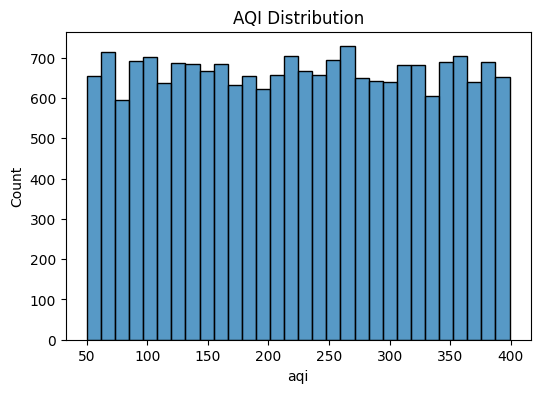

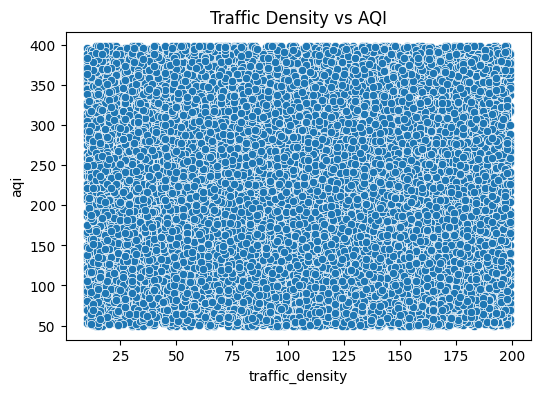

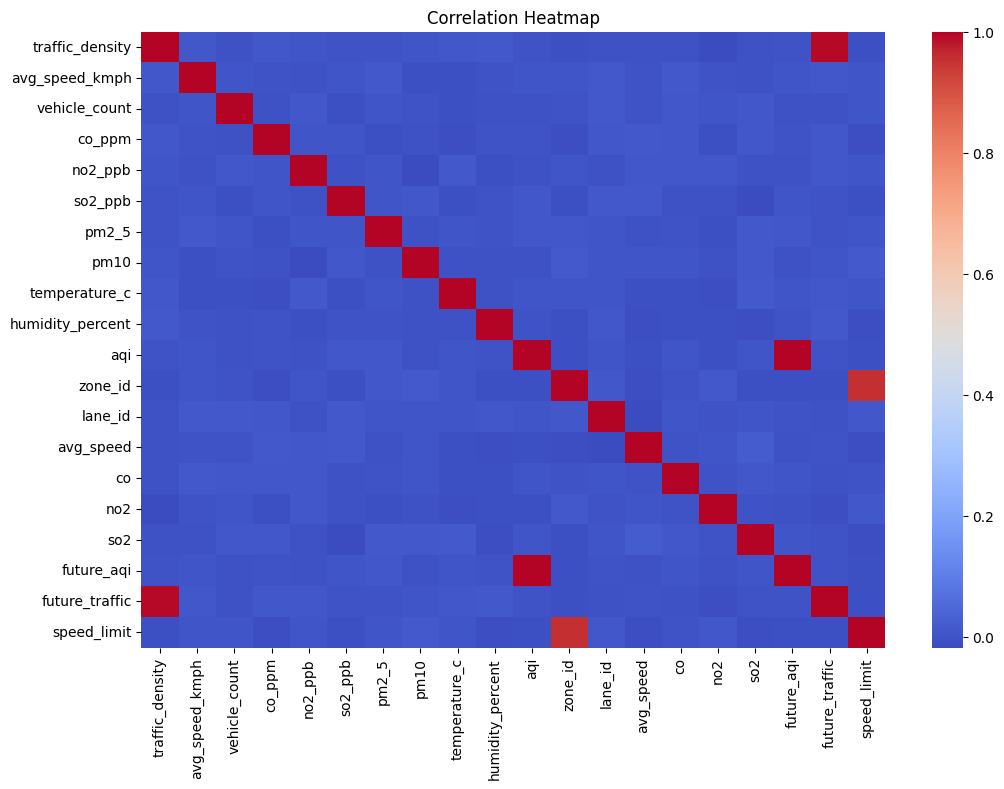


Model: Logistic Regression
Accuracy: 0.80675
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      2664
           1       0.72      0.70      0.71      1336

    accuracy                           0.81      4000
   macro avg       0.78      0.78      0.78      4000
weighted avg       0.81      0.81      0.81      4000


Model: Decision Tree
Accuracy: 0.75675
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      2664
           1       0.63      0.65      0.64      1336

    accuracy                           0.76      4000
   macro avg       0.73      0.73      0.73      4000
weighted avg       0.76      0.76      0.76      4000


Model: Random Forest
Accuracy: 0.8055
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      2664
           1       0.69      0.75      0.72      1336

    accuracy                           0.81      4000
   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("/Users/sunilmaddipatla/Desktop/smart city iot analytics for traffic and air quality monitoring/Data/smart_city_iot_speedlimit_dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour

# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Fill missing values if any
df.fillna(df.median(numeric_only=True), inplace=True)

# Remove timestamp after extraction
df.drop(columns=["timestamp"], inplace=True)

# AQI Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["aqi"], bins=30)
plt.title("AQI Distribution")
plt.show()

# Traffic Density vs AQI
plt.figure(figsize=(6,4))
sns.scatterplot(x="traffic_density", y="aqi", data=df)
plt.title("Traffic Density vs AQI")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=["int64","float64"]).corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Rush hour feature
df["rush_hour"] = (((df["hour"] >= 7) & (df["hour"] <= 10)) |
                   ((df["hour"] >= 17) & (df["hour"] <= 20))).astype(int)

# Overspeed target
df["overspeed"] = (df["avg_speed"] > df["speed_limit"]).astype(int)

# Pollution index
df["pollution_index"] = (
    0.4 * df["pm10"] +
    0.3 * df["no2"] +
    0.3 * df["co"]
)

# Congestion index
df["congestion_index"] = df["traffic_density"] / df["traffic_density"].max()

# Weather discomfort
df["weather_discomfort"] = (df["temperature_c"] + df["humidity_percent"]) / 2

features = [
    "vehicle_count",
    "traffic_density",
    "avg_speed",
    "pm10","no2","co",
    "temperature_c","humidity_percent",
    "rush_hour",
    "pollution_index",
    "congestion_index",
    "weather_discomfort"
]

X = df[features]
y = df["overspeed"]   # Binary classification target


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Support Vector Machine": SVC(kernel="rbf"),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = []

for name, model in models.items():
    print("\n==============================")
    print(f"Model: {name}")
    
    if name in ["Logistic Regression", "Support Vector Machine"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\nModel Comparison:\n")
print(results_df)
